### Step #1: Explore and prep data

In [11]:
import pandas as pd

df = pd.read_csv('bank-additional-full.csv', delimiter=';')

In [12]:
cols_to_drop = ['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df = df.drop(columns=cols_to_drop).rename(columns={'job': 'job_type', 'default': 'default_status', 
                                                   'housing': 'housing_loan_status', 'loan': 'personal_loan_status', 
                                                   'contact': 'contact_type', 'month': 'contact_month', 
                                                   'day_of_week': 'contact_day_of_week', 'campaign': 'num_contacts', 
                                                   'pdays': 'days_last_contact', 'previous': 'previous_contacts', 
                                                   'poutcome': 'previous_outcome', 
                                                   'y': 'result'
                                                    })
df['result'] = df['result'].replace({'yes': 1, 'no': 0})

In [13]:
df.head()

,age,job_type,marital,education,default_status,housing_loan_status,personal_loan_status,contact_type,contact_month,contact_day_of_week,num_contacts,days_last_contact,previous_contacts,previous_outcome,result
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   41188 non-null  int64 
 1   job_type              41188 non-null  object
 2   marital               41188 non-null  object
 3   education             41188 non-null  object
 4   default_status        41188 non-null  object
 5   housing_loan_status   41188 non-null  object
 6   personal_loan_status  41188 non-null  object
 7   contact_type          41188 non-null  object
 8   contact_month         41188 non-null  object
 9   contact_day_of_week   41188 non-null  object
 10  num_contacts          41188 non-null  int64 
 11  days_last_contact     41188 non-null  int64 
 12  previous_contacts     41188 non-null  int64 
 13  previous_outcome      41188 non-null  object
 14  result                41188 non-null  int64 
dtypes: int64(5), object(10)
memory usage

In [15]:
df['result'].value_counts()

result
0    36548
1     4640
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='result')
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=8)

### Step #2: Build a pipeline of training

In [17]:
from sklearn.pipeline import Pipeline
from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier

estimators = [
    ('encoder', TargetEncoder()),
    ('clf', XGBClassifier(random_state=8)) # can customize objective function with the objective parameter
]
pipe = Pipeline(steps=estimators)
pipe

,steps,"[('encoder', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,None
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


### Step #3: Set up hyperparameter tuning

In [18]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Example pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])


In [19]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

search_space = {
    'clf__max_depth': Integer(2, 8),
    'clf__learning_rate': Real(0.001, 1.0, prior='log-uniform'),
    'clf__n_estimators': Integer(50, 500),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    'clf__gamma': Real(0.0, 10.0)
}

opt = BayesSearchCV(
    pipe,
    search_space,
    cv=3,
    n_iter=10,
    scoring='roc_auc',
    random_state=8
)

# Fit example
# opt.fit(X_train, y_train)


### Step #3: Set up hyperparameter tuning

In [20]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

search_space = {
    'clf__max_depth': Integer(2,8),
    'clf__learning_rate': Real(0.001, 1.0, prior='log-uniform'),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    'clf__colsample_bylevel': Real(0.5, 1.0),
    'clf__colsample_bynode' : Real(0.5, 1.0),
    'clf__reg_alpha': Real(0.0, 10.0),
    'clf__reg_lambda': Real(0.0, 10.0),
    'clf__gamma': Real(0.0, 10.0)
}

opt = BayesSearchCV(pipe, search_space, cv=3, n_iter=10, scoring='roc_auc', random_state=8) 

### Step #4: Train the XGBoost model

In [22]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Suppose you know which columns are categorical vs numeric
categorical_cols = ['job', 'marital', 'education']  # replace with your real column names
numeric_cols = ['age', 'balance', 'duration']       # replace with your numeric features

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Full pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])


### Step: 5 Test the model

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# -------------------------
# Example: Load your dataset
# -------------------------
# Replace this with your own dataframe
df = pd.read_csv("bank-additional-full.csv", sep=";")

X = df.drop("y", axis=1)   # features
y = (df["y"] == "yes").astype(int)  # convert target to 0/1

# Identify categorical vs numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# -------------------------
# Preprocessing
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

# -------------------------
# Full pipeline
# -------------------------
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])

# -------------------------
# Search space for BayesSearchCV
# -------------------------
search_space = {
    "clf__max_depth": Integer(2, 8),
    "clf__learning_rate": Real(0.001, 1.0, prior="log-uniform"),
    "clf__n_estimators": Integer(50, 500),
    "clf__subsample": Real(0.5, 1.0, prior="uniform"),
    "clf__colsample_bytree": Real(0.5, 1.0, prior="uniform"),
    "clf__gamma": Real(0.0, 10.0)
}

# -------------------------
# Train/test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# Bayesian optimization
# -------------------------
opt = BayesSearchCV(
    pipe,
    search_space,
    cv=3,
    n_iter=10,
    scoring="roc_auc",
    random_state=8,
    verbose=2
)

opt.fit(X_train, y_train)

print("Best score:", opt.best_score_)
print("Best params:", opt.best_params_)


Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:38] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.5331080642783614, clf__gamma=4.524641467896757, clf__learning_rate=0.001649041217445871, clf__max_depth=6, clf__n_estimators=56, clf__subsample=0.7744989638517832; total time=   0.3s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:39] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.5331080642783614, clf__gamma=4.524641467896757, clf__learning_rate=0.001649041217445871, clf__max_depth=6, clf__n_estimators=56, clf__subsample=0.7744989638517832; total time=   0.3s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:39] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.5331080642783614, clf__gamma=4.524641467896757, clf__learning_rate=0.001649041217445871, clf__max_depth=6, clf__n_estimators=56, clf__subsample=0.7744989638517832; total time=   0.3s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:39] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7098720980049984, clf__gamma=0.7903448118180724, clf__learning_rate=0.0010695607963804486, clf__max_depth=4, clf__n_estimators=111, clf__subsample=0.6284428247848861; total time=   0.4s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:40] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7098720980049984, clf__gamma=0.7903448118180724, clf__learning_rate=0.0010695607963804486, clf__max_depth=4, clf__n_estimators=111, clf__subsample=0.6284428247848861; total time=   0.4s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:40] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7098720980049984, clf__gamma=0.7903448118180724, clf__learning_rate=0.0010695607963804486, clf__max_depth=4, clf__n_estimators=111, clf__subsample=0.6284428247848861; total time=   0.3s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:41] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.6301181140809947, clf__gamma=5.407634226774718, clf__learning_rate=0.0010879729176870164, clf__max_depth=3, clf__n_estimators=125, clf__subsample=0.5595333551495748; total time=   0.3s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:41] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.6301181140809947, clf__gamma=5.407634226774718, clf__learning_rate=0.0010879729176870164, clf__max_depth=3, clf__n_estimators=125, clf__subsample=0.5595333551495748; total time=   0.5s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:42] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.6301181140809947, clf__gamma=5.407634226774718, clf__learning_rate=0.0010879729176870164, clf__max_depth=3, clf__n_estimators=125, clf__subsample=0.5595333551495748; total time=   0.5s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:42] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7750018497221565, clf__gamma=1.228874883192527, clf__learning_rate=0.2990344608627261, clf__max_depth=7, clf__n_estimators=445, clf__subsample=0.7975949925015471; total time=   1.2s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:44] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7750018497221565, clf__gamma=1.228874883192527, clf__learning_rate=0.2990344608627261, clf__max_depth=7, clf__n_estimators=445, clf__subsample=0.7975949925015471; total time=   1.3s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:45] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7750018497221565, clf__gamma=1.228874883192527, clf__learning_rate=0.2990344608627261, clf__max_depth=7, clf__n_estimators=445, clf__subsample=0.7975949925015471; total time=   1.2s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:46] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.9425384185492701, clf__gamma=8.19191361247969, clf__learning_rate=0.017249323857067383, clf__max_depth=3, clf__n_estimators=485, clf__subsample=0.9468613805207762; total time=   1.5s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:48] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.9425384185492701, clf__gamma=8.19191361247969, clf__learning_rate=0.017249323857067383, clf__max_depth=3, clf__n_estimators=485, clf__subsample=0.9468613805207762; total time=   1.4s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:50] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.9425384185492701, clf__gamma=8.19191361247969, clf__learning_rate=0.017249323857067383, clf__max_depth=3, clf__n_estimators=485, clf__subsample=0.9468613805207762; total time=   1.5s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:51] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.5056087634867006, clf__gamma=2.001444807208957, clf__learning_rate=0.021490648392940095, clf__max_depth=5, clf__n_estimators=183, clf__subsample=0.604705365357568; total time=   0.8s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:52] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.5056087634867006, clf__gamma=2.001444807208957, clf__learning_rate=0.021490648392940095, clf__max_depth=5, clf__n_estimators=183, clf__subsample=0.604705365357568; total time=   0.8s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:53] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.5056087634867006, clf__gamma=2.001444807208957, clf__learning_rate=0.021490648392940095, clf__max_depth=5, clf__n_estimators=183, clf__subsample=0.604705365357568; total time=   0.8s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:54] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.935225370284509, clf__gamma=0.7810391518173433, clf__learning_rate=0.006009180886422016, clf__max_depth=7, clf__n_estimators=225, clf__subsample=0.8334676463173443; total time=   1.4s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:55] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.935225370284509, clf__gamma=0.7810391518173433, clf__learning_rate=0.006009180886422016, clf__max_depth=7, clf__n_estimators=225, clf__subsample=0.8334676463173443; total time=   1.2s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:57] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.935225370284509, clf__gamma=0.7810391518173433, clf__learning_rate=0.006009180886422016, clf__max_depth=7, clf__n_estimators=225, clf__subsample=0.8334676463173443; total time=   1.6s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:58] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.8255063664935096, clf__gamma=9.132919958734231, clf__learning_rate=0.04440088763773788, clf__max_depth=7, clf__n_estimators=267, clf__subsample=0.5368266265401924; total time=   0.9s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:00] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.8255063664935096, clf__gamma=9.132919958734231, clf__learning_rate=0.04440088763773788, clf__max_depth=7, clf__n_estimators=267, clf__subsample=0.5368266265401924; total time=   1.1s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:01] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.8255063664935096, clf__gamma=9.132919958734231, clf__learning_rate=0.04440088763773788, clf__max_depth=7, clf__n_estimators=267, clf__subsample=0.5368266265401924; total time=   1.0s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:02] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7160044460033754, clf__gamma=1.269685078540195, clf__learning_rate=0.21701524362599195, clf__max_depth=2, clf__n_estimators=176, clf__subsample=0.625745599745765; total time=   0.5s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:02] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7160044460033754, clf__gamma=1.269685078540195, clf__learning_rate=0.21701524362599195, clf__max_depth=2, clf__n_estimators=176, clf__subsample=0.625745599745765; total time=   0.4s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:03] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.7160044460033754, clf__gamma=1.269685078540195, clf__learning_rate=0.21701524362599195, clf__max_depth=2, clf__n_estimators=176, clf__subsample=0.625745599745765; total time=   0.4s
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:04] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.6854728136721551, clf__gamma=9.432584843118107, clf__learning_rate=0.9995603769684693, clf__max_depth=8, clf__n_estimators=443, clf__subsample=0.7688300679265652; total time=   0.5s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:05] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.6854728136721551, clf__gamma=9.432584843118107, clf__learning_rate=0.9995603769684693, clf__max_depth=8, clf__n_estimators=443, clf__subsample=0.7688300679265652; total time=   0.6s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:05] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END clf__colsample_bytree=0.6854728136721551, clf__gamma=9.432584843118107, clf__learning_rate=0.9995603769684693, clf__max_depth=8, clf__n_estimators=443, clf__subsample=0.7688300679265652; total time=   0.7s


C:\Users\HP\anaconda3\envs\py311_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:07] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best score: 0.9455110281291814
Best params: OrderedDict([('clf__colsample_bytree', 0.8255063664935096), ('clf__gamma', 9.132919958734231), ('clf__learning_rate', 0.04440088763773788), ('clf__max_depth', 7), ('clf__n_estimators', 267), ('clf__subsample', 0.5368266265401924)])


In [31]:
opt.best_estimator_


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
opt.best_score_

0.9455110281291814

In [33]:
opt.score(X_test, y_test)

0.9549139994811076

In [34]:
opt.predict(X_test)


array([0, 0, 0, ..., 1, 0, 0])

In [35]:
opt.predict_proba(X_test)


array([[0.9960917 , 0.0039083 ],
       [0.90943336, 0.09056661],
       [0.8241064 , 0.1758936 ],
       ...,
       [0.3459018 , 0.6540982 ],
       [0.76333827, 0.23666172],
       [0.9909828 , 0.00901725]], dtype=float32)

### Step #6: Measure feature importance (optional)


In [36]:
opt.best_estimator_.steps


[('preprocessor',
  ColumnTransformer(transformers=[('num', StandardScaler(),
                                   ['age', 'duration', 'campaign', 'pdays',
                                    'previous', 'emp.var.rate', 'cons.price.idx',
                                    'cons.conf.idx', 'euribor3m',
                                    'nr.employed']),
                                  ('cat', OneHotEncoder(handle_unknown='ignore'),
                                   ['job', 'marital', 'education', 'default',
                                    'housing', 'loan', 'contact', 'month',
                                    'day_of_week', 'poutcome'])])),
 ('clf',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=0.8255063664935096, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric='logloss', feature_types=None, feature_weig

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

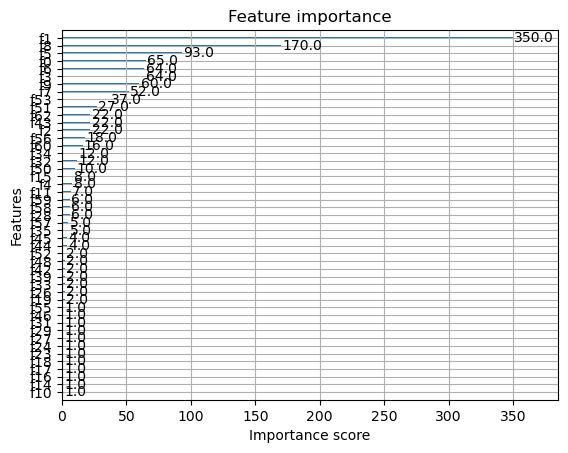

In [37]:
from xgboost import plot_importance

xgboost_step = opt.best_estimator_.steps[1]
xgboost_model = xgboost_step[1]
plot_importance(xgboost_model)
